In [29]:
import numpy as np
import pandas as pd
import matplotlib_fontja
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import math
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


In [30]:
import os
print("現在の場所:", os.getcwd())
print("フォルダ内のファイル:", os.listdir('.'))

現在の場所: /Users/seito/Data-n-Math
フォルダ内のファイル: ['reviews.csv', 'app_old.py', 'lasso_pred.png', 'lasso.ipynb', '__pycache__', 'model.py', 'locations.csv', 'lasso_coef.png', '.gitignore', '.venv', 'app.py', 'lasso_path.png', 'app_improved.py', 'app_backup.py', '.git', 'lasso_cv.png']


In [31]:
from model import calc_scale, fit_lasso, fit_lasso_cv, predict_scale

print('model.py のインポート完了')

model.py のインポート完了


In [32]:
# 実データ読み込み
try:
    df_real = pd.read_csv('locations.csv')
    
    # 存在しない scale 列を探すのではなく、新しく計算して列を追加する
    df_real['scale'] = df_real.apply(
        lambda r: calc_scale(r['duty'], r['crowd'], r['fun']), axis=1
    )
    
    print(f'実データ: {len(df_real)}件')
    display(df_real[['name', 'duty', 'crowd', 'fun', 'scale']])
    
except FileNotFoundError:
    print('locations.csv が見つかりません')
    df_real = pd.DataFrame()

実データ: 45件


,name,duty,crowd,fun,scale
0,葛西駅,4,4,2,1.80
1,バイト先A,5,4,2,1.95
2,バイト先B,4,3,2,1.70
3,インターン先,5,5,1,2.15
4,東京駅,3,5,3,1.65
5,新宿駅,3,5,3,1.65
6,渋谷駅,3,5,4,1.55
7,池袋駅,3,5,3,1.65
8,秋葉原駅,2,4,5,1.20
9,上野駅,2,4,4,1.30


In [33]:
# ダミーデータ生成（n=100件）
# 数理モデル: scale = 1 + 0.15*duty + 0.10*crowd - 0.10*fun + ノイズ
np.random.seed(42)
n = 100

df_dummy = pd.DataFrame({
    'duty':  np.random.randint(1, 6, n).astype(float),
    'crowd': np.random.randint(1, 6, n).astype(float),
    'fun':   np.random.randint(1, 6, n).astype(float),
})

# 理論値にガウスノイズを加える
noise = np.random.normal(0, 0.05, n)
df_dummy['scale'] = df_dummy.apply(
    lambda r: calc_scale(r['duty'], r['crowd'], r['fun']), axis=1
) + noise

print(f'ダミーデータ: {len(df_dummy)}件')
print(df_dummy.describe().round(3))

ダミーデータ: 100件
          duty    crowd      fun    scale
count  100.000  100.000  100.000  100.000
mean     3.070    2.930    2.860    1.466
std      1.402    1.437    1.371    0.279
min      1.000    1.000    1.000    0.744
25%      2.000    1.750    1.000    1.292
50%      3.000    3.000    3.000    1.434
75%      4.000    4.000    4.000    1.693
max      5.000    5.000    5.000    2.024


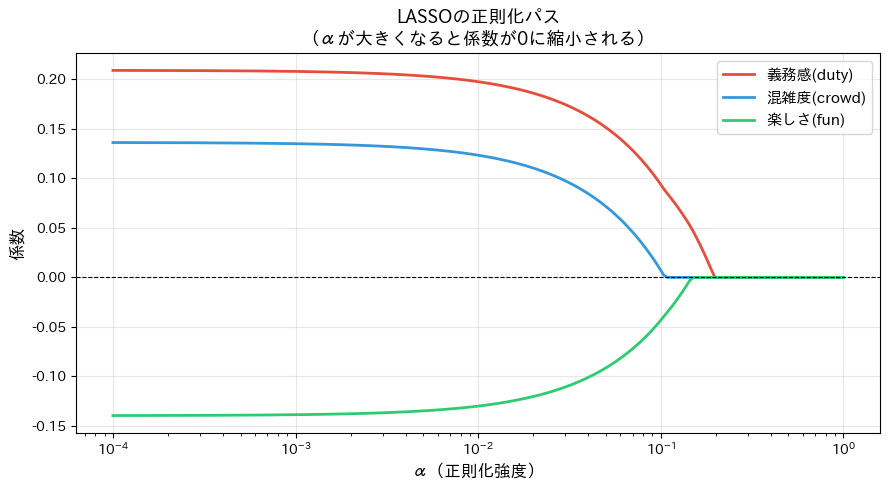

→ αが大きいほど係数が0に縮小されることが確認できる


In [34]:
feature_cols = ['duty', 'crowd', 'fun']
X = df_dummy[feature_cols].values
y = df_dummy['scale'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-4, 0, 200)
coefs = {col: [] for col in feature_cols}

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    for i, col in enumerate(feature_cols):
        coefs[col].append(lasso.coef_[i])

# プロット
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']
labels = ['義務感(duty)', '混雑度(crowd)', '楽しさ(fun)']

for col, color, label in zip(feature_cols, colors, labels):
    ax.plot(alphas, coefs[col], color=color, label=label, lw=2)

ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('α（正則化強度）', fontsize=12)
ax.set_ylabel('係数', fontsize=12)
ax.set_title('LASSOの正則化パス\n（αが大きくなると係数が0に縮小される）', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=150)
plt.show()
print('→ αが大きいほど係数が0に縮小されることが確認できる')

最適 α = 0.000534


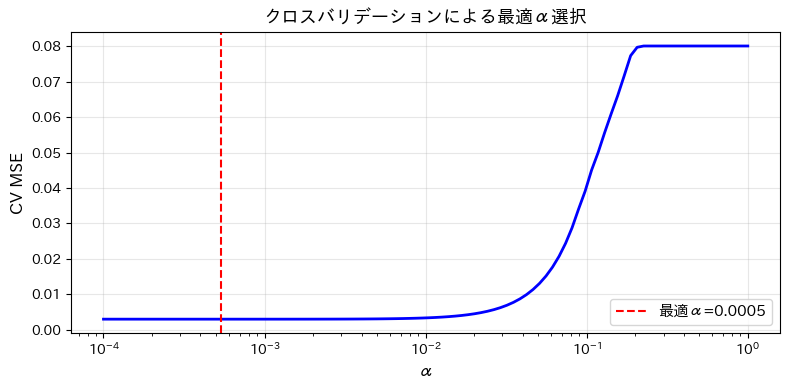

In [35]:
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 0, 100),
    cv=5,
    max_iter=10000
)
lasso_cv.fit(X_scaled, y)

best_alpha = lasso_cv.alpha_
print(f'最適 α = {best_alpha:.6f}')

# αごとの平均MSEをプロット
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lasso_cv.alphas_, mean_mse, 'b-', lw=2)
ax.axvline(best_alpha, color='red', ls='--', label=f'最適α={best_alpha:.4f}')
ax.set_xscale('log')
ax.set_xlabel('α', fontsize=12)
ax.set_ylabel('CV MSE', fontsize=12)
ax.set_title('クロスバリデーションによる最適α選択', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lasso_cv.png', dpi=150)
plt.show()

In [36]:
result = fit_lasso(df_dummy, alpha=best_alpha)

print('=== LASSO回帰結果 ===')
print(f'切片         : {result["intercept"]:.4f}')
print()
print('係数:')
for feat, coef in result['coef'].items():
    bar = '█' * int(abs(coef) * 50)
    sign = '+' if coef >= 0 else '-'
    print(f'  {feat:8s}: {sign}{abs(coef):.4f}  {bar}')

print()
print(f'R²（訓練）   : {result["r2_train"]:.4f}')
print(f'R²（テスト） : {result["r2_test"]:.4f}')
print(f'RMSE（テスト）: {result["rmse_test"]:.4f}')

=== LASSO回帰結果 ===
切片         : 1.4731

係数:
  duty    : +0.2066  ██████████
  crowd   : +0.1350  ██████
  fun     : -0.1394  ██████

R²（訓練）   : 0.9603
R²（テスト） : 0.9678
RMSE（テスト）: 0.0536


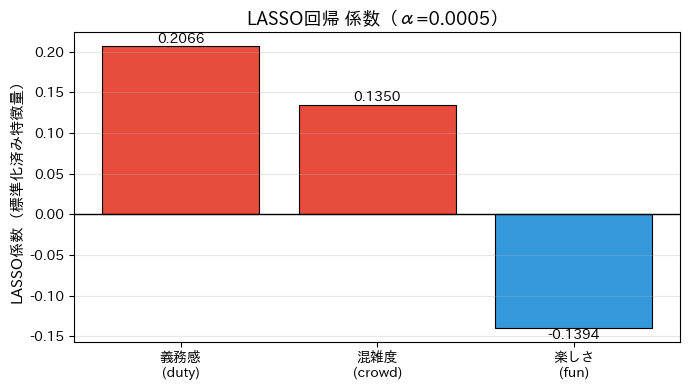

赤: scaleを増加させる要因 / 青: scaleを減少させる要因


In [37]:
# 係数の棒グラフ
fig, ax = plt.subplots(figsize=(7, 4))
features = list(result['coef'].keys())
coef_vals = list(result['coef'].values())
labels_jp = ['義務感\n(duty)', '混雑度\n(crowd)', '楽しさ\n(fun)']
colors = ['#e74c3c' if v > 0 else '#3498db' for v in coef_vals]

bars = ax.bar(labels_jp, coef_vals, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('LASSO係数（標準化済み特徴量）', fontsize=11)
ax.set_title(f'LASSO回帰 係数（α={best_alpha:.4f}）', fontsize=13)

for bar, val in zip(bars, coef_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.001 * (1 if val >= 0 else -1),
            f'{val:.4f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lasso_coef.png', dpi=150)
plt.show()
print('赤: scaleを増加させる要因 / 青: scaleを減少させる要因')

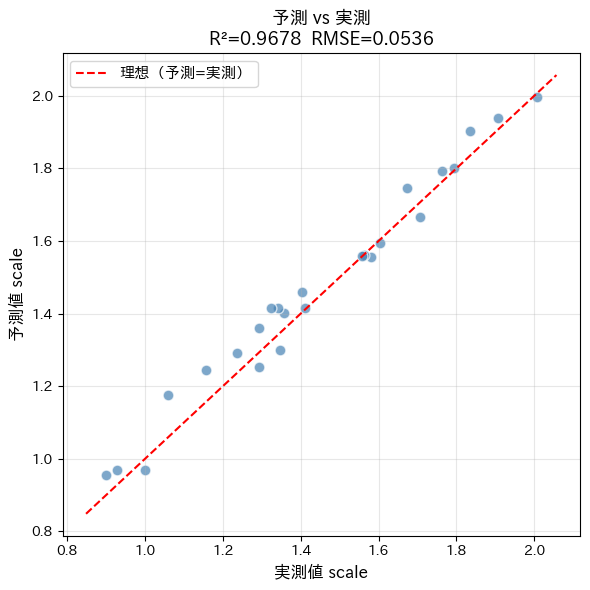

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

best_lasso = Lasso(alpha=best_alpha, max_iter=10000)
best_lasso.fit(X_train, y_train)
y_pred = best_lasso.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white', s=60)

lims = [min(y_test.min(), y_pred.min()) - 0.05,
        max(y_test.max(), y_pred.max()) + 0.05]
ax.plot(lims, lims, 'r--', lw=1.5, label='理想（予測=実測）')
ax.set_xlabel('実測値 scale', fontsize=12)
ax.set_ylabel('予測値 scale', fontsize=12)
ax.set_title(f'予測 vs 実測\nR²={r2_score(y_test, y_pred):.4f}  RMSE={math.sqrt(mean_squared_error(y_test, y_pred)):.4f}',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lasso_pred.png', dpi=150)
plt.show()

In [39]:
# 仮の新地点を予測
test_places = [
    {'名前': '病院（高義務感）',   'duty': 5, 'crowd': 4, 'fun': 1},
    {'名前': '遊園地（楽しい）',   'duty': 1, 'crowd': 3, 'fun': 5},
    {'名前': 'スーパー（普通）',   'duty': 3, 'crowd': 3, 'fun': 3},
    {'名前': '図書館（静か）',     'duty': 2, 'crowd': 1, 'fun': 4},
]

print('=== 新地点の scale 予測 ===')
print(f'{"場所":<20} {"duty":>5} {"crowd":>6} {"fun":>5} | {"理論値":>7} {"予測値":>7}')
print('-' * 60)

for place in test_places:
    theory = calc_scale(place['duty'], place['crowd'], place['fun'])
    pred   = predict_scale(
        result['model'], result['scaler'],
        place['duty'], place['crowd'], place['fun']
    )
    print(f"{place['名前']:<20} {place['duty']:>5} {place['crowd']:>6} {place['fun']:>5} | {theory:>7.3f} {pred:>7.3f}")

=== 新地点の scale 予測 ===
場所                    duty  crowd   fun |     理論値     予測値
------------------------------------------------------------
病院（高義務感）                 5      4     1 |   2.050   2.050
遊園地（楽しい）                 1      3     5 |   0.950   0.954
スーパー（普通）                 3      3     3 |   1.450   1.455
図書館（静か）                  2      1     4 |   1.000   1.016
